# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [2]:
%load_ext autoreload
%autoreload 2

## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

In [7]:
ts = np.loadtxt('datasets/Rotation Matrix.txt')

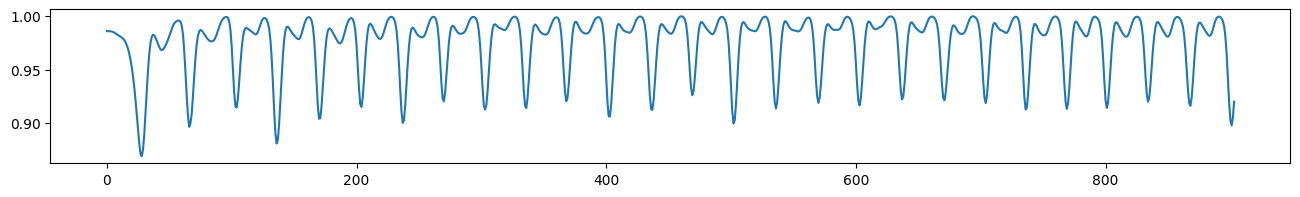

In [8]:
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts)

https://stumpy.readthedocs.io/en/latest/api.html#stumpy.stump

The third column consists of the left matrix profile indices, and the fourth column consists of the right matrix profile indices

In [10]:
m = 30
mp = stumpy.stump(ts, m=m)

In [11]:
mp

array([[1.9769746973168418, 110, -1, 110],
       [2.063449526807942, 110, -1, 110],
       [2.0503696018633137, 111, -1, 111],
       ...,
       [0.39661064496599774, 642, 642, -1],
       [0.33236406380970557, 643, 643, -1],
       [0.3326332097017604, 644, 644, -1]], dtype=object)

Слайды 30 и 31.

[Алгоритмы alts и allc](http://localhost:8888/edit/Desktop/Cemester%203/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%B8%20%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%20%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D1%85%20%D1%80%D1%8F%D0%B4%D0%BE%D0%B2%20%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%B0%D0%BC%D0%B8%20%D0%B8%D1%81%D0%BA%D1%83%D1%81%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE%20%D0%B8%D0%BD%D1%82%D0%B5%D0%BB%D0%BB%D0%B5%D0%BA%D1%82%D0%B0/2025-Galiulin-TimeSeriesCourse/slides/05%20Chains.pdf?)

https://stumpy.readthedocs.io/en/latest/Tutorial_Time_Series_Chains.html

https://stumpy.readthedocs.io/en/latest/_modules/stumpy/chains.html

In [14]:
all_chain_set, unanchored_chain = stumpy.allc(mp[:, 2], mp[:, 3])

In [15]:
unanchored_chain # the longest chain

array([144, 376, 410, 644, 841])

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Для нахождения цепочки в начале нужно было вычислить матричный профиль. Найденные левый и правый матричные профили необходимы для работы алгоритма allc для нахождения всех цепочем и незакрепленной цепочки, котрорая является самой длинной по определению. Найденная цепочка состоит из 5 звеньев.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

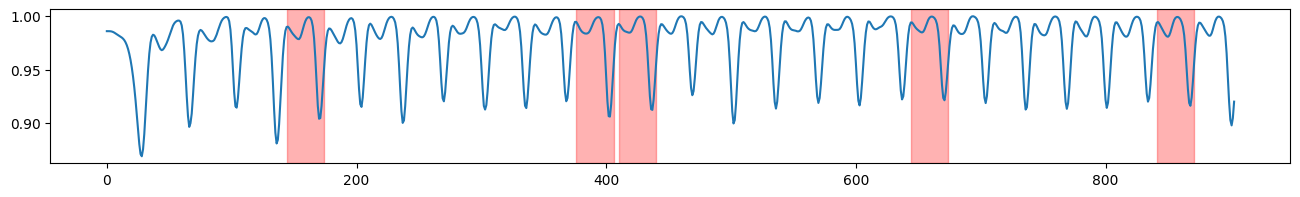

In [20]:
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts)

for idx in unanchored_chain:
    ax.axvspan(idx, idx + m, color='red', alpha=0.3)

plt.show()

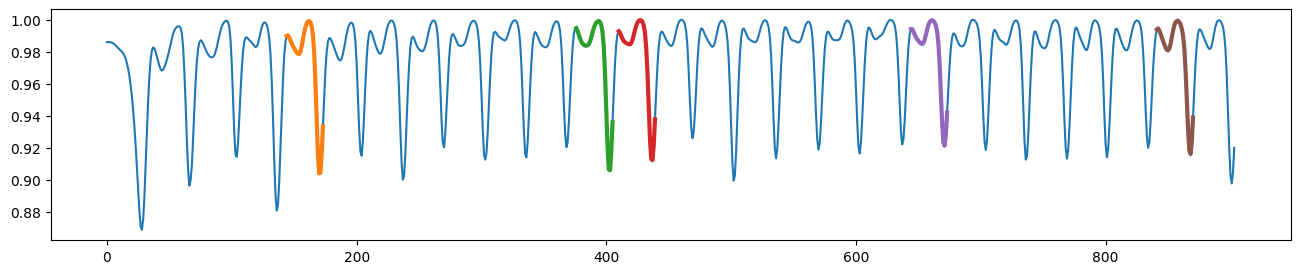

In [21]:
fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(ts)

for idx in unanchored_chain:
    ax.plot(
        np.arange(idx, idx + m),
        ts[idx:idx + m],
        linewidth=3
    )

plt.show()

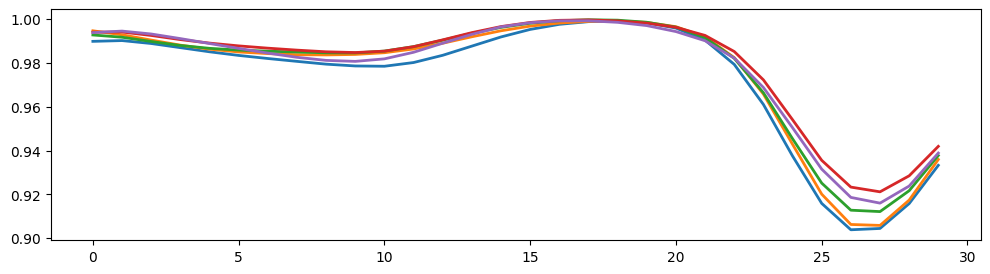

In [22]:
fig, ax = plt.subplots(figsize=(12, 3))

for idx in unanchored_chain:
    ax.plot(ts[idx:idx + m], linewidth=2)

plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Найденные звенья цепочки врительно соответсвуют друг другу, наблюдается лишь незначительное изменение. Очевидно, что форма звенье будет отличаться от заданной длины подпоследовательности, поэтому для точного нахождения цепочек необходимо понимание предметной области.

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [27]:
delta = ts[unanchored_chain[-2]] - ts[unanchored_chain[-3]]
delta

0.0012862099999999543

In [28]:
predict = ts[unanchored_chain[-2]] + delta

In [29]:
abs(predict - ts[unanchored_chain[-1]])

0.0014917799999999426

In [30]:
segment2 = ts[unanchored_chain[-3] : unanchored_chain[-3] + m]
segment1 = ts[unanchored_chain[-2] : unanchored_chain[-2] + m]
segment = ts[unanchored_chain[-1] : unanchored_chain[-1] + m]

In [31]:
delta = segment1 - segment2
predict = segment1 + delta

In [32]:
np.mean(predict - segment)

0.004565659000000011

In [33]:
mean_squared_error(segment, predict)

4.1365089415876655e-05

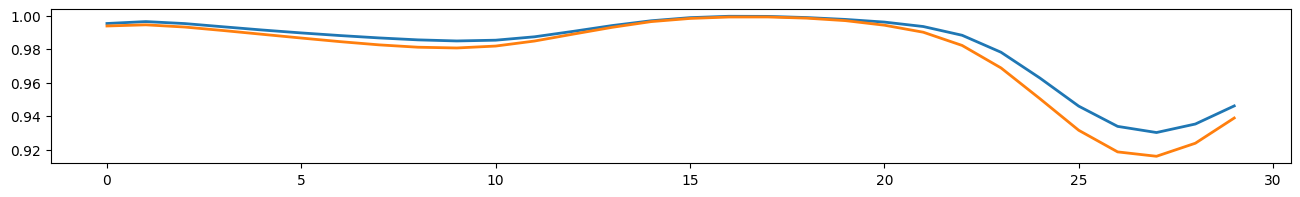

In [58]:
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(predict, linewidth=2)
ax.plot(segment, linewidth=2)

plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Предсказанное значение последного звена цепочки оказалось визуально похожим на истинное значение.